# 202235203 고수호
# **6week - abalone.csv 데이터에 대한 DL_Classification**

# **# 라이브러리 임포트**

In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

# **# 데이터 세트 불러오기**

In [211]:
path = '/content/drive/MyDrive/Colab Notebooks/6week/abalone.csv'
df = pd.read_csv(path)
df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


# **# 결측치 확인**

In [212]:
df.isnull().sum()

,0
id,0
Sex,0
Length,0
Diameter,0
Height,0
Whole_weight,0
Shucked_weight,0
Viscera_weight,0
Shell_weight,0
Rings,0


# **# 'Rings'에 따른 분포 시각화**
**주로 8 ~ 12에 데이터가 몰려있음**

/tmp/ipykernel_6675/275296874.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['Rings'], bins=29, kde=False, palette='viridis')


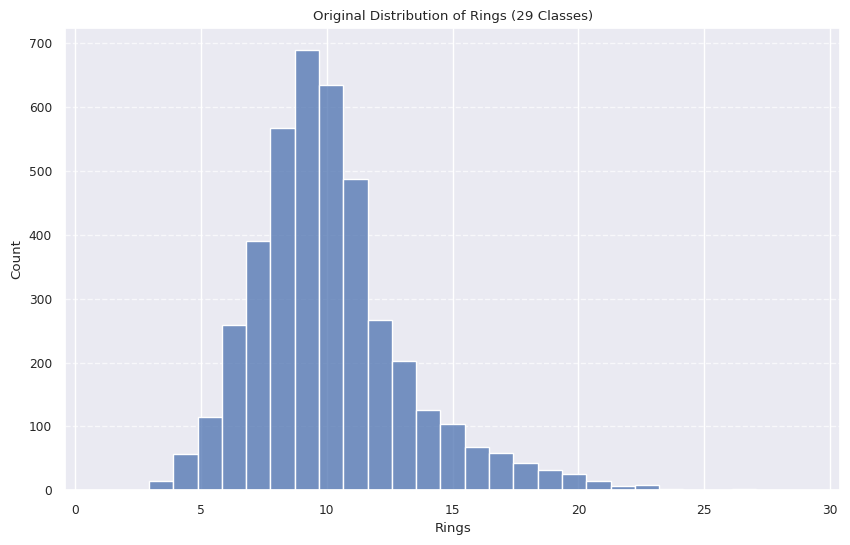

In [213]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Rings'], bins=29, kde=False, palette='viridis')
plt.title('Original Distribution of Rings (29 Classes)')
plt.xlabel('Rings')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **# 'Rings'클래스 분류 및 상관관계 분석**
 **'Rings' 값을 데이터 불균형이 일어나지 않도록 4개의 클래스로 분류**
* Class 0: ~7  
* Class 1: 8~9
* Class 2: 10~11
* Class 3: 12~  
```bins = [0, 8, 10, 12, df['Rings'].max() + 1]```
*  각 구간의 경계를 정의 (7이하, 8 ~ 9, 10 ~ 11, 12이상).   
```labels = [0, 1, 2, 3]```
* 새로운 클래스에 할당할 숫자 레이블.
```df['Rings'] = pd.cut(df['Rings'], bins=bins, labels=labels, right=False, include_lowest=True).astype(int)```
* bins: 어디서부터 어디까지 자를 것인지 정하는 기준점 리스트.
* labels: 잘린 구간에 붙일 이름.
* right=False: 구간을 [시작, 끝) 형태로 만듦. 즉, 시작값은 포함하고 끝값은 포함하지 않는다.
* include_lowest=True: 가장 첫 번째 구간의 시작값(가장 작은 값)을 포함할지 결정.
* .astype(int): pd.cut의 결과는 'Category' 타입인데, 이를 딥러닝 모델이 계산하기 좋게 **정수(0, 1, 2, 3)** 로 변환.


<Axes: >

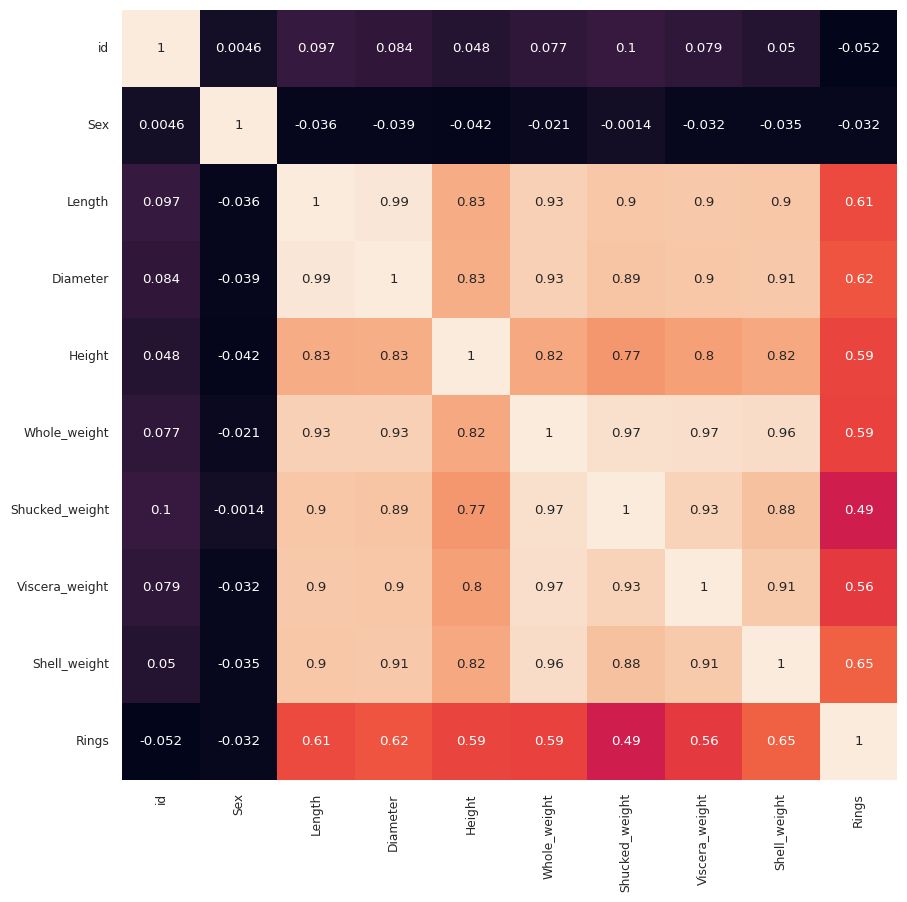

In [214]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

bins = [0, 8, 10, 12, df['Rings'].max() + 1]
labels = [0, 1, 2, 3]
df['Rings'] = pd.cut(df['Rings'], bins=bins, labels=labels, right=False, include_lowest=True).astype(int)

df_corr = df.corr()
plt.figure(figsize=(10,10))
sns.set(font_scale = 0.8)
sns.heatmap(df_corr, annot=True, cbar=False)

# **# 'Rings' 분류에 따른 분포 시각화**
**데이터 불균형을 최소화 하는 4개의 클래스로 분류**

/tmp/ipykernel_6675/944707816.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['Rings'], bins=len(labels), kde=False, palette='viridis')


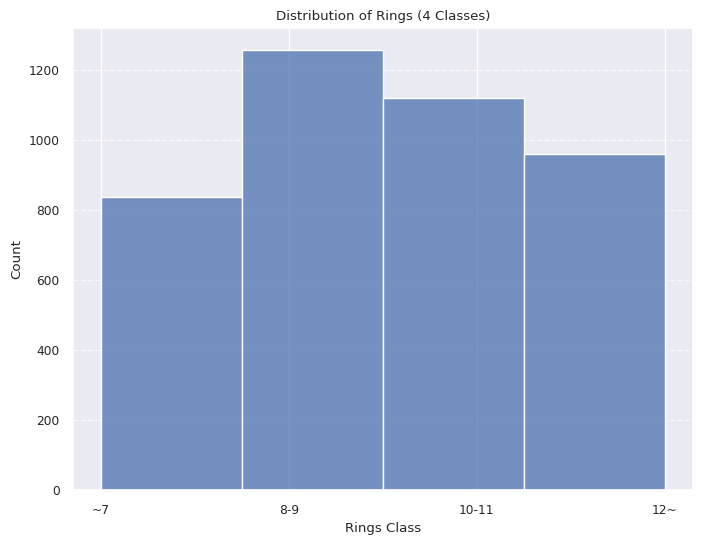

In [215]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Rings'], bins=len(labels), kde=False, palette='viridis')
plt.title('Distribution of Rings (4 Classes)')
plt.xlabel('Rings Class')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2, 3], labels=['~7', '8-9', '10-11', '12~'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **# 종속변수(y) 설정 및 원-핫 인코딩**

In [216]:
y = df['Rings']
Y = pd.get_dummies(y).values

# **# 독립변수(X) 설정 및 Numpy 배열 변환**

In [217]:
X=df.drop(['Rings', 'id'], axis=1)
X = X.values

# **# 데이터셋 분리 (Training & Test Set) 및 StandardScaler**
**StandardScaler(표준화)** : 데이터의 특징들을 평균이 0, 표준편차가 1인 표준정규분포 형태로 변환하는 과정.  

```scaler = StandardScaler() ```
* 표준화(Z-score Normalization)를 수행할 계산기 객체
```X_train = scaler.fit_transform(X_train)```
* 학습 데이터(X_train)의 평균($\mu$)과 표준편차($\sigma$)를 계산해서 기억 후 변환
```X_test = scaler.transform(X_test)```
* 테스트 데이터(X_test)를 기억한 수치를 바탕으로 변환

In [218]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

# StandardScaler 적용
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **# 딥러닝 모델 구성 및 학습**

In [219]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam


model = Sequential()

model.add(Dense(64,input_shape=(X.shape[1],),activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(Y.shape[1],activation='softmax'))

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model_history=model.fit(x=X_train, y=y_train, epochs=50, batch_size=32,validation_data= (X_test,y_test))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4654 - loss: 1.1338 - val_accuracy: 0.5634 - val_loss: 1.0187
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5621 - loss: 0.9946 - val_accuracy: 0.5921 - val_loss: 0.9604
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5840 - loss: 0.9556 - val_accuracy: 0.6017 - val_loss: 0.9264
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5926 - loss: 0.9309 - val_accuracy: 0.6017 - val_loss: 0.9081
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5962 - loss: 0.9248 - val_accuracy: 0.6005 - val_loss: 0.9028
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5884 - loss: 0.9169 - val_accuracy: 0.6089 - val_loss: 0.8972
Epoch 7/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5941 - loss: 0.9131 - val_accuracy: 0.5993 - val_loss: 0.8992
Epoch 8/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5917 - loss: 0.9068 - val_accuracy: 0.

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_84 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,758 (38.12 KB)

 Trainable params: 3,252 (12.70 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,506 (25.42 KB)

# **# 모델 예측 및 클래스 변환**

In [220]:
y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test,axis=1)
y_pred_class = np.argmax(y_pred,axis=1)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


# **# 학습 및 검증 손실 시각화**

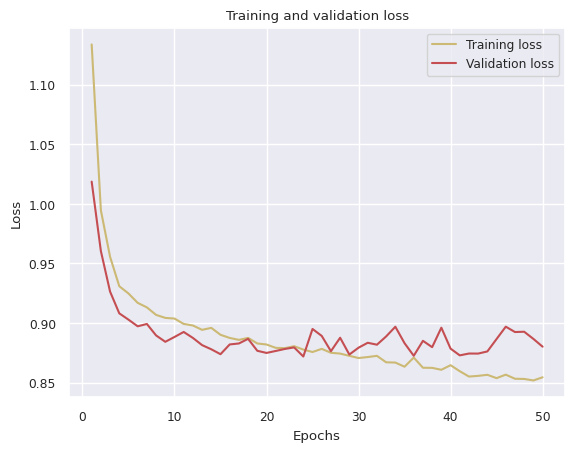

In [221]:
loss =model_history.history['loss']
val_loss =model_history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# **# 학습 및 검증 정확도 시각화**

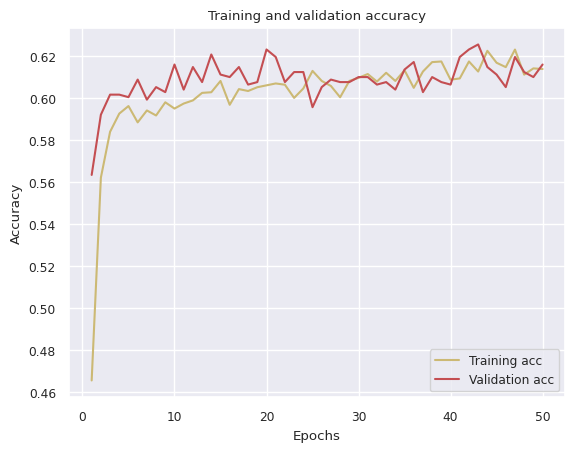

In [222]:
acc =model_history.history['accuracy']
val_acc =model_history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()